🍴 Culinary AI Bot Started



You:  תן לי מתכון


Bot: אני מצאתי בשבילך: קערת שייק פירות (Smoothie Bowl) 🍌



You:  האוכל היה מעולה


Bot: 👨‍🍳 הנה רעיון קולינרי בשבילך: פנקייקים עם סירופ מייפל ופירות 🍓


...


You:  אהבתי


Bot: 👨‍🍳 הנה רעיון קולינרי בשבילך: אורז מוקפץ עם ירקות ורוטב סויה 🥢



You:  exsit


Bot: 👨‍🍳 הנה רעיון קולינרי בשבילך: עוגת שוקולד חמה עם רוטב שוקולד נוזלי 🍫



You:  exit


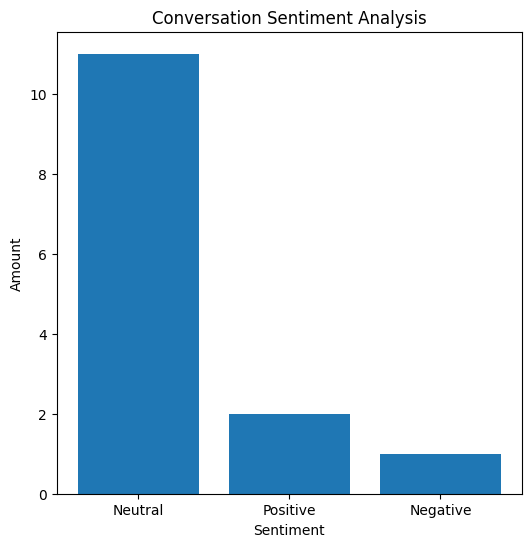

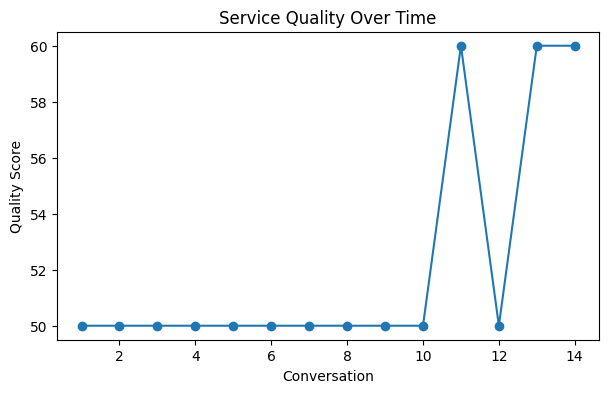

In [4]:
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt


# =========================
# Custom Exceptions
# =========================

class AIConnectionError(Exception):
    pass


# =========================
# Storage Manager
# =========================

class HistoryManager:

    FILE_NAME = "history.json"

    def load_history(self):
        try:
            if not os.path.exists(self.FILE_NAME):
                return []

            with open(self.FILE_NAME, "r", encoding="utf-8") as file:
                return json.load(file)

        except Exception as e:
            raise Exception(f"Failed loading history: {e}")


    def save_history(self, history):

        try:
            with open(
                self.FILE_NAME,
                "w",
                encoding="utf-8"
            ) as file:

                json.dump(
                    history,
                    file,
                    ensure_ascii=False,
                    indent=4
                )

        except Exception as e:
            raise Exception(f"Failed saving history: {e}")



# =========================
# Mock AI Service
# =========================

class AIService:

    def __init__(self, api_key=None):
        self.api_key = api_key

        # מוק דטה יותר עשיר
        self.recipes = {
            "מתוק": [
                "עוגת שוקולד חמה עם רוטב שוקולד נוזלי ",
                "פנקייקים עם סירופ מייפל ופירות ",
                "גלידת וניל ביתית עם עוגיות "
            ],
            "מלוח": [
                "פסטה שמנת פטריות עשירה ",
                "שקשוקה ישראלית קלאסית ",
                "אורז מוקפץ עם ירקות ורוטב סויה "
            ],
            "בריא": [
                "סלט קינואה עם ירקות טריים ",
                "קערת שייק פירות (Smoothie Bowl) ",
                "עוף אפוי עם בטטה וברוקולי "
            ],
            "מהיר": [
                "טוסט גבינה מותכת עם ירקות ",
                "חביתה עם גבינה ועגבניות ",
                "פסטה 10 דקות עם שום ושמן זית "
            ]
        }

    def get_response(self, question):

        try:
            if self.api_key is None:
                raise Exception("no api key")

            return "AI אמיתי (אם היה לך API)"

        except:
            return self.mock_response(question)

    def mock_response(self, question):

        q = question.lower()

        if "מתוק" in q:
            return self._pick("מתוק")

        if "מלוח" in q:
            return  self._pick("מלוח")

        if "בריא" in q:
            return self._pick("בריא")

        if "מהיר" in q or "קל" in q:
            return "⚡ " + self._pick("מהיר")

        if "מתכון" in q:
            return "אני מצאתי בשבילך: " + self._random_recipe()

        if "לא אהבתי" in q or "גרוע" in q:
            return "😅 אוקי, אני אנסה משהו אחר: " + self._random_recipe()

        return "👨‍🍳 הנה רעיון קולינרי בשבילך: " + self._random_recipe()

    def _pick(self, key):
        import random
        return random.choice(self.recipes[key])

    def _random_recipe(self):
        import random
        all_recipes = []
        for r in self.recipes.values():
            all_recipes.extend(r)
        return random.choice(all_recipes)


# =========================
# Sentiment Analysis
# =========================

class SentimentAnalyzer:


    positive_words = [
        "טעים",
        "מעולה",
        "מצוין",
        "אהבתי",
        "מדהים",
        "טוב"
    ]


    negative_words = [
        "גרוע",
        "לא טעים",
        "אכזבה",
        "רע",
        "קר",
        "לא אהבתי"
    ]



    def analyze(self,text):

        score = 0


        for word in self.positive_words:

            if word in text:
                score += 1


        for word in self.negative_words:

            if word in text:
                score -= 1



        if score > 0:

            return "Positive"


        elif score < 0:

            return "Negative"


        else:

            return "Neutral"





# =========================
# Visualization
# =========================

class Visualization:


    def show_sentiment_graph(self, history):

        sentiments = {}


        for item in history:

            s = item["sentiment"]

            sentiments[s] = sentiments.get(s,0)+1



        plt.figure(figsize=(6,6))

        plt.bar(
            sentiments.keys(),
            sentiments.values()
        )


        plt.title(
            "Conversation Sentiment Analysis"
        )


        plt.xlabel(
            "Sentiment"
        )

        plt.ylabel(
            "Amount"
        )


        plt.show()



    def show_quality_graph(self, history):


        scores = []

        number = []


        value = 50


        for index,item in enumerate(history):

            number.append(index+1)


            if item["sentiment"]=="Positive":

                value += 10


            elif item["sentiment"]=="Negative":

                value -= 10


            scores.append(value)



        plt.figure(figsize=(7,4))


        plt.plot(
            number,
            scores,
            marker="o"
        )


        plt.title(
            "Service Quality Over Time"
        )


        plt.xlabel(
            "Conversation"
        )


        plt.ylabel(
            "Quality Score"
        )


        plt.show()




# =========================
# Main Bot
# =========================


class CulinaryBot:


    def __init__(self):

        self.history_manager = HistoryManager()

        self.history = self.history_manager.load_history()

        self.ai = AIService()

        self.sentiment = SentimentAnalyzer()

        self.visual = Visualization()



    def chat(self, question):


        answer = self.ai.get_response(question)


        sentiment = self.sentiment.analyze(question)



        conversation = {


            "time":
                str(datetime.now()),


            "question":
                question,


            "answer":
                answer,


            "sentiment":
                sentiment
        }



        self.history.append(conversation)


        self.history_manager.save_history(
            self.history
        )


        return answer



    def show_reports(self):

        self.visual.show_sentiment_graph(
            self.history
        )


        self.visual.show_quality_graph(
            self.history
        )




# =========================
# Run Program
# =========================


if __name__ == "__main__":


    bot = CulinaryBot()


    print(
        "🍴 Culinary AI Bot Started"
    )


    while True:


        user_input = input(
            "\nYou: "
        )


        if user_input.lower()=="exit":

            break



        response = bot.chat(
            user_input
        )


        print(
            "Bot:",
            response
        )



    bot.show_reports()